<a href="https://colab.research.google.com/github/sujal910/Learning_PyTorch/blob/main/02_PyTorch_WorkFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to the notebook

This notebook documents the typical end-to-end workflow in PyTorch, starting from data preparation and model definition to training, evaluation, and saving models. The goal is to create a clear conceptual map of how different components in PyTorch fit together during the machine learning process.



# PyTorch Workflow

1. `Data Preparation`

   Collect, clean, and convert the data into PyTorch tensors or datasets. This step includes loading data, preprocessing, normalization, and splitting into training and testing sets.

2. `Model Definition`

   Define the neural network or mathematical model that maps inputs to outputs. This includes selecting layers, activation functions, and the architecture of the network.

3. `Loss Function Selection`

   Choose a loss function that measures the difference between the model’s predictions and the true targets. The loss guides the training process.

4. `Optimizer Selection`
   Choose an optimization algorithm that updates the model’s parameters based on computed gradients. This includes selecting the learning rate and optimization method such as SGD or Adam.

5. `Training Loop`

   Iteratively train the model by performing forward propagation to get predictions, computing the loss, backpropagating gradients, and updating the model parameters. This loop is repeated for multiple epochs.

6. `Evaluation`

   Test the trained model on validation or test data to measure performance and generalization. This step is done without updating model parameters.

7. `Saving and Loading`

   Optionally save the trained model’s parameters to disk and reload them later for inference or continued training.




In [14]:
import torch
from torch import nn
import matplotlib.pyplot as plt



## Core Libraries Used

1. `torch.nn`

The torch.nn module is the core PyTorch library used for building neural networks. It provides ready-made building blocks such as layers, activation functions, and loss functions.

Its main purpose is to help define models as compositions of layers and operations. Instead of manually writing mathematical equations, torch.nn allows you to express them using reusable components.

---

2. `matplotlib`

Matplotlib is a Python library used for data visualization. It is commonly used in machine learning projects to visualize datasets, training progress, and model performance.

Its main purpose is to help humans understand data and learning behavior through plots and graphs.

Matplotlib is typically used to:

* Plot loss curves during training to see whether the model is learning.
* Visualize predictions versus actual values.
* Explore datasets through scatter plots, histograms, and line charts.
* Debug models by visually inspecting outputs.

---



## 1. Data Preparation

Data preparation is the process of collecting, cleaning, transforming, and organizing raw data into a format that a machine learning model can understand and learn from. In PyTorch, this usually means converting data into tensors and organizing them into datasets and data loaders.

The quality of the data strongly affects the quality of the model. Well-prepared data leads to faster training, better convergence, and more reliable results.

The main goals of data preparation are:

* Convert data into numerical form

* Ensure consistent shape and data type

* Normalize or scale values if needed

* Split data into training and testing sets

* Batch and shuffle data for training

In [15]:
# Creating a linear regration witn some known *parameters*.
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10] , y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [16]:
len(X) , len(y)

(50, 50)

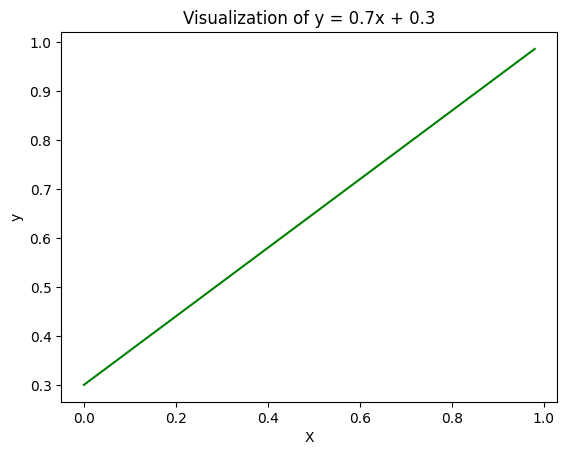

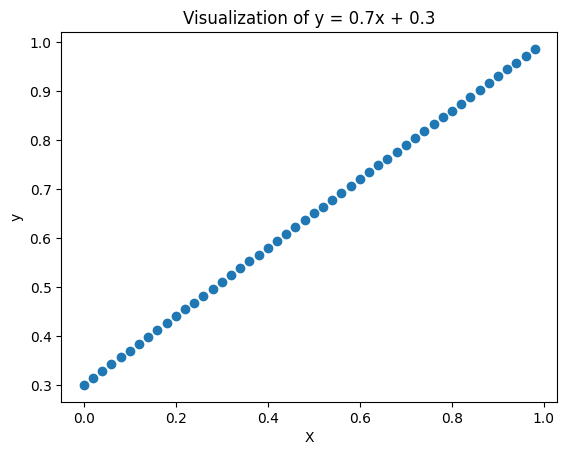

In [17]:
# This is to visiualize what is going on.
import torch
import matplotlib.pyplot as plt

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

# Convert to numpy for plotting
X_np = X.numpy()
y_np = y.numpy()

# Plot
plt.plot(X_np , y_np , c="g")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Visualization of y = 0.7x + 0.3")
plt.show()
plt.scatter(X_np, y_np)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Visualization of y = 0.7x + 0.3")
plt.show()


In [18]:
import torch

# Generate input data
x = torch.randn(10, 1)

# Generate labels with a known relationship
y = 3 * x + 2

print(x)
print(y)
print(x.shape, y.shape)


tensor([[ 0.2345],
        [ 0.2303],
        [-1.1229],
        [-0.1863],
        [ 2.2082],
        [-0.6380],
        [ 0.4617],
        [ 0.2674],
        [ 0.5349],
        [ 0.8094]])
tensor([[ 2.7034],
        [ 2.6910],
        [-1.3686],
        [ 1.4410],
        [ 8.6246],
        [ 0.0860],
        [ 3.3850],
        [ 2.8021],
        [ 3.6047],
        [ 4.4281]])
torch.Size([10, 1]) torch.Size([10, 1])


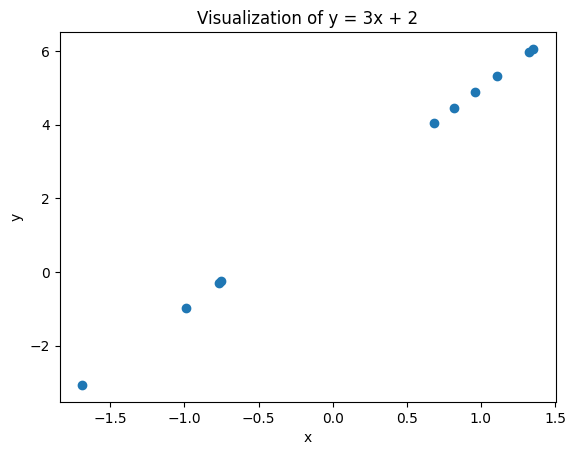

In [19]:
# If you want to visvalize this
import torch
import matplotlib.pyplot as plt

# Generate input data
x = torch.randn(10, 1)

# Generate labels
y = 3 * x + 2

# Convert tensors to numpy for plotting
x_np = x.numpy()
y_np = y.numpy()

# Plot
plt.scatter(x_np, y_np)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Visualization of y = 3x + 2")
plt.show()


In [20]:
# When working with real datasets, we usually use Dataset and DataLoader.

from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

dataset , loader


(<torch.utils.data.dataset.TensorDataset at 0x7b486cd38ef0>,
 <torch.utils.data.dataloader.DataLoader at 0x7b486cd389e0>)

### Why Batching and Shuffling Matter

`Batching`:
Instead of feeding all data at once, we feed small groups (batches) of data. This makes training more memory-efficient and often improves convergence.

`Shuffling`:
Shuffling prevents the model from learning patterns caused by the order of the data instead of the data itself.

###  The Three Datasets in Machine Learning

In machine learning, data is usually divided into three separate parts so that we can train a model properly and evaluate it fairly.

These three datasets are:

1. `Training Dataset`

The training dataset is the portion of data used to teach the model. The model learns patterns, relationships, and parameters from this data.

During training, the model sees this data many times and adjusts its internal parameters to minimize the loss.

This dataset should be the largest portion of the total data.

Purpose: To learn.

2. `Validation Dataset`

The validation dataset is used during training to monitor the model’s performance on unseen data. It helps in tuning hyperparameters such as learning rate, number of layers, and number of epochs.

The model does not learn from this dataset directly. It is only used for evaluation and decision-making.

Purpose: To tune and select the best model.

3. `Test Dataset`

The test dataset is used only after training and validation are complete. It provides an unbiased estimate of the final model’s performance.

The model should never see the test data during training or tuning.

Purpose: To evaluate final performance.

---



In [21]:
# we have this data created Now we will use this data and create a traning and test Dataset *split*

# This is the previous code written
import torch

# Creating a linear regration witn some known *parameters*.
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visvalising by crating a plot predition

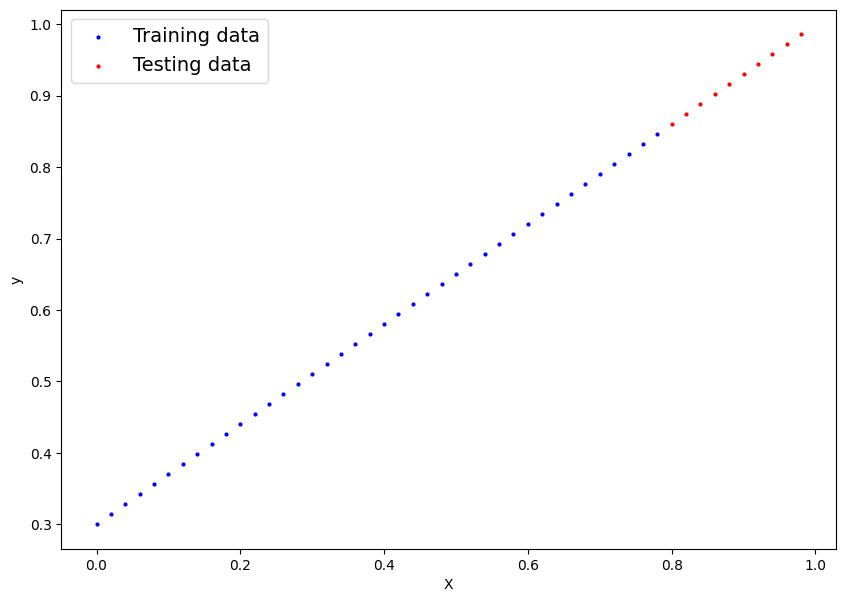

In [22]:
## Visvalising by crating a plot predition
import matplotlib.pyplot as plt
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  plt.figure(figsize=(10, 7))

  # Ploting train dataset
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Ploting test dataset
  plt.scatter(test_data, test_labels, c="r", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions , c="g", s=4, label="Predictions")

  plt.legend(prop={"size": 14})
  plt.xlabel("X")
  plt.ylabel("y")
  plt.show()

plot_predictions()

In [23]:
import torch
from torch.utils.data import TensorDataset, random_split

# Create synthetic data
x = torch.randn(1000, 1)
y = 3 * x + 2 + 0.1 * torch.randn_like(x)  # small noise

# Create dataset
dataset = TensorDataset(x, y)

# Define split sizes (70%, 15%, 15%)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


Train size: 700
Validation size: 150
Test size: 150


## 2 .Model Definition
✅ What is Model Definition?

It means:

* Creating a class that represents your neural network

* Telling PyTorch what layers exist

* Defining how data flows through them

In [24]:
import torch
from torch import nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # single input feature → single output feature
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))

    def forward(self, x : torch.tensor):
        return self.weights * x + self.bias




| Line                                     | Meaning                               |
| ---------------------------------------- | ------------------------------------- |
| `class LinearRegressionModel(nn.Module)` | Create your model class               |
| `super().__init__()`                     | Initialize PyTorch internals          |
| `nn.Linear(1,1)`                         | Linear layer → y = wx + b             |
| `forward()`                              | Defines how input flows through model |


## 🌱 First: What problem are we solving?

We have a model:
[
y = w x + b
]

We have data ((x, y_{true})).
We want to find **the best values of (w) and (b)** so that (y) is close to (y_{true}).

So the question is:

> ❓ *How should we change (w) and (b) to reduce the error?*

That’s where **loss, gradient, backpropagation, and gradient descent** come in.

---

### 🧩 Step 1 — What is the Loss?

Loss is just a **number that measures how bad the model is.**

Example:
                     
                     loss = (y_pred ​− y_true​)2


* Big loss → bad model
* Small loss → good model

So the goal is:

> 🎯 **Minimize the loss**

---

### 🧭 Step 2 — What does "Gradient" mean?

Gradient = **slope** = **how fast loss changes when parameters change.**

Think of a hill:

* You are standing on a hill (loss surface).
* You want to go to the bottom (minimum loss).
* The **gradient tells you the steepest uphill direction.**

So if you go in the **opposite direction**, you go downhill.

That’s why:

> **Gradient = direction of increase**
> **-Gradient = direction of decrease**

---

### 🔄 Step 3 — What is Backpropagation?

**Backpropagation is NOT optimization.**

It is just:

> 🔁 **The method used to compute gradients of loss with respect to parameters.**

That is:

    
                              ∂w/∂loss ​, ∂b/∂loss​

It uses the **chain rule of calculus** to propagate error backwards from output → parameters.

So:

| Term                | Meaning           |
| ------------------- | ----------------- |
| Forward pass        | Compute output    |
| Compute loss        | Measure error     |
| **Backpropagation** | Compute gradients |

---

### 🏃 Step 4 — What is Gradient Descent?

Once you know the gradients, you **update the parameters**:

                  w = w − α(∂w/∂loss)
	                
                  ​𝑏 = 𝑏 − 𝛼(∂𝑙oss/∂b)
             
             Where α = Learning rate
	​
This step is called **Gradient Descent**.

So:

| Backpropagation    | Gradient Descent |
| ------------------ | ---------------- |
| Computes gradients | Uses gradients   |
| Math               | Optimization     |
| Analysis           | Action           |

---

### 🧠 Mental Picture

Imagine this:

* Loss is a valley.
* You are blindfolded.
* You can feel the slope under your feet (gradient).
* You step in the opposite direction (gradient descent).
* Repeat until you reach bottom.

---

### 🔗 Full Cycle

1️⃣ Guess (w, b)
2️⃣ Compute prediction
3️⃣ Compute loss
4️⃣ Backprop → find gradients
5️⃣ Gradient descent → update parameters
6️⃣ Repeat

---

### 🟢 Final simple definitions

| Term             | Meaning in one line      |
| ---------------- | ------------------------ |
| Loss             | How wrong the model is   |
| Gradient         | How loss changes         |
| Backpropagation  | How we compute gradients |
| Gradient Descent | How we update parameters |

---



### Checking the content of our PyTorch Modle
what's inside our modle by using ` .parmeters() `


In [25]:
from numpy import mod
# Creating a random seed

torch.manual_seed(42)

# creating a intance of a modle ( this is a Subclass of nn.Module )

model_0 = LinearRegressionModel()

print(model_0.state_dict()) # This lists named parametres
print("")
print(list(model_0.parameters()))  # This lists the parameters in a list form

OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [26]:
weight , bias # we need values of the model to be close to these values.
# Close to these values the model will be better at prediting .
# Most of the time we will not have these Ideal Values .

(0.7, 0.3)



# 🚀 PyTorch Essentials

| Component                | Category      | What it is                       | Why it matters / Use                     |
| ------------------------ | ------------- | -------------------------------- | ---------------------------------------- |
| `torch`                  | Core          | Main PyTorch library             | Foundation for tensors & deep learning   |
| Tensor                   | Core          | Multi-dimensional data structure | Stores data & model parameters           |
| `torch.cuda`             | Hardware      | GPU computing module             | Speeds up deep learning massively        |
| `torch.device`           | Hardware      | CPU/GPU selector                 | Enables device flexibility               |
| `torch.autograd`         | Core          | Automatic differentiation engine | Computes gradients for backpropagation   |
| `torch.nn`               | Neural Nets   | Neural network building module   | Defines layers, models, losses           |
| `nn.Module`              | Model         | Base class for models            | Backbone of every PyTorch model          |
| `nn.Parameter`           | Model         | Trainable tensor                 | Represents learnable weights             |
| `torch.nn.functional`    | Ops           | Functional API for layers        | Lightweight alternative to nn layers     |
| `nn.Linear`              | Layer         | Fully connected layer            | Used in MLPs and classifiers             |
| `nn.Conv2d`              | Layer         | Convolutional layer              | Core of CNNs for images                  |
| `nn.LSTM`                | Layer         | Long Short-Term Memory           | Used in NLP and time-series              |
| `nn.Embedding`           | Layer         | Word embedding layer             | Used in NLP models                       |
| Activation Functions     | Non-linearity | ReLU, Sigmoid, GELU, etc.        | Enables models to learn complex patterns |
| Loss Function            | Training      | Measures prediction error        | Guides model learning                    |
| `nn.CrossEntropyLoss`    | Loss          | Classification loss              | Used in multi-class problems             |
| `nn.MSELoss`             | Loss          | Regression loss                  | Used in continuous prediction            |
| `torch.optim`            | Training      | Optimizer module                 | Updates model weights                    |
| Adam                     | Optimizer     | Adaptive learning rate optimizer | Most popular in deep learning            |
| SGD                      | Optimizer     | Gradient descent optimizer       | Used in classic ML                       |
| `lr_scheduler`           | Training      | Learning rate controller         | Improves convergence                     |
| `torch.utils.data`       | Data          | Data handling module             | Manages datasets efficiently             |
| `Dataset`                | Data          | Abstract dataset class           | Defines how data is stored               |
| `DataLoader`             | Data          | Batch data loader                | Enables mini-batch training              |
| Batch                    | Data          | Group of samples                 | Improves training efficiency             |
| Sampler                  | Data          | Sampling strategy                | Controls data selection                  |
| `torchvision`            | Vision        | Computer vision library          | Extends PyTorch for images               |
| `torchvision.datasets`   | Vision        | Prebuilt datasets                | MNIST, CIFAR, ImageNet                   |
| `torchvision.transforms` | Vision        | Image preprocessing              | Data augmentation                        |
| `torchvision.models`     | Vision        | Pretrained models                | Transfer learning                        |
| Forward Pass             | Training      | Input → Output computation       | Produces predictions                     |
| Backpropagation          | Training      | Gradient computation             | Core learning mechanism                  |
| Gradient                 | Math          | Loss derivative                  | Drives weight updates                    |
| `model.train()`          | Mode          | Training mode                    | Activates dropout & batchnorm            |
| `model.eval()`           | Mode          | Evaluation mode                  | Disables dropout                         |
| `torch.no_grad()`        | Mode          | No gradient mode                 | Faster inference                         |
| `state_dict()`           | Model         | Parameter dictionary             | Saves model state                        |
| `torch.save()`           | Utility       | Save model                       | Model persistence                        |
| `torch.load()`           | Utility       | Load model                       | Model restoration                        |
| `nn.Sequential`          | Model         | Sequential layer container       | Simplifies model building                |
| `nn.ModuleList`          | Model         | List of layers                   | Dynamic architectures                    |
| `nn.ModuleDict`          | Model         | Dictionary of layers             | Flexible model design                    |
| `torch.nn.init`          | Utility       | Weight initialization            | Stabilizes training                      |

---







### Predicting with torch.inference_mode()


`torch.inference_mode()`  is a PyTorch context manager used during prediction to disable gradient computation and optimize performance, making inference faster and more memory-efficient.

* To check modles predictive power let's see how well it predicts the ` Y_test ` on the based on `X_test` .
* when we pass data through our model it's going to run through the the `forward()` method .

In [27]:
model_0.eval()
with torch.inference_mode():
    y_pred = model_0(X_test)

print(y_pred)


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


In [28]:
y_pred = model_0(X_test)  # both of these are same but the inference.mode turn down the gardinat mode .
print(y_pred , y_test , y_pred == y_test )

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>) tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]]) tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])


In [32]:
with torch.no_grad(): # this is also one way of doing it without the grad however the inference_mode is prefered .
  y_pred = model_0(X_test)
print(y_pred , y_test)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]]) tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


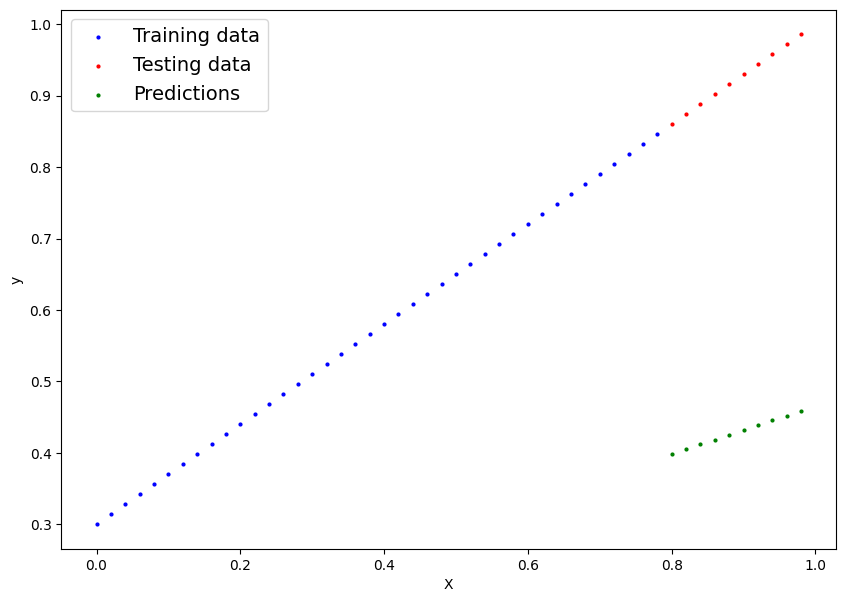

In [33]:
plot_predictions(predictions=y_pred)

Here is your content with **correct LaTeX added everywhere it should be**, fixed formatting, and no extra explanation — just clean math + Markdown.

---

# 3. Training the Model (Required Theory)

---

## 1️⃣ What is Model Training?

Model training is the process of finding the best parameters (weights & bias) so that the model predicts correctly.

Mathematically, we want to find ( (w, b) ) such that:


                  y_pred ​≈ y_true​

So training is:

Searching for optimal parameters that minimize error.

---

## 2️⃣ Components Required for Training

To train any neural network, we need **4 fundamental things**:

### (A) Model

A function with parameters.

Example:

```latex
y = wx + b
```

Parameters:

```latex
(w, b)
```

---

### (B) Loss Function (Cost Function)

Loss function measures how wrong the model is.

Example: Mean Squared Error (MSE)

              L = n.1∑(ypred​−ytrue​)^2


Purpose:

Convert prediction error into a single number.

---

### (C) Optimization Algorithm (Optimizer)

Optimizer updates parameters to reduce loss.

#### Gradient Descent

Update rule:


\begin{aligned}
w &= w - \alpha \frac{\partial L}{\partial w}, \\
b &= b - \alpha \frac{\partial L}{\partial b}.
\end{aligned}


Where:


\begin{aligned}
\alpha &= \text{learning rate}, \\
\frac{\partial L}{\partial w} &= \text{gradient}.
\end{aligned}


Purpose:

Move parameters in the direction that reduces loss.

---

### (D) Backpropagation

Backpropagation is the method to compute gradients.

It uses the chain rule:


\begin{aligned}
\frac{\partial L}{\partial w}, \quad \frac{\partial L}{\partial b}
\end{aligned}


Purpose:

Understand how each parameter affects the loss.

---

## 3️⃣ Training Loop (The Core Theory)

Training is iterative.

### Step 1 — Forward Pass


           x ---→ ypred​


---

### Step 2 — Compute Loss

L(ypred​,ytrue​)`

---

### Step 3 — Backward Pass (Backpropagation)


              ∂w/∂L​,∂b/∂L​

---

### Step 4 — Parameter Update (Gradient Descent)
            w:= w − α.∂l/∂Lw
---

### Step 5 — Repeat

Repeat until loss is minimal.

This repetition is called an **epoch**.

---

## 4️⃣ Important Training Concepts (Theory)

###🔹 Epoch

One full pass through the training dataset.

---

### 🔹 Batch

Subset of data used in one step.

Types:

* Batch Gradient Descent
* Mini-batch Gradient Descent
* Stochastic Gradient Descent

---

### 🔹 Learning Rate


alpha


---

### 🔹 Convergence

When loss stops decreasing.

---

###🔹 Overfitting & Underfitting

* Underfitting: model too simple
* Overfitting: model memorizes data

---

## 5️⃣ Conceptual Diagram

```text
Input Data
   ↓
Model (w, b)
   ↓
Prediction (y_pred)
   ↓
Loss Function
   ↓
Backpropagation (gradients)
   ↓
Optimizer (update w, b)
   ↓
Repeat (epochs)
```

---

## 6️⃣ Deep Insight

Training is solving an optimization problem:

```latex
\min_{w,b} L(w,b)
```

